# AFI - testing

### 1.database merging

In [1]:
import pandas as pd
import glob

enrolment_files = glob.glob("data/enrollment/*.csv")

enrolment_df = pd.concat(
    [pd.read_csv(f) for f in enrolment_files],
    ignore_index=True
)

enrolment_df.drop_duplicates(inplace=True)

enrolment_df.shape


(983072, 7)

In [2]:
biometric_files = glob.glob("data/biometric/*.csv")

biometric_df = pd.concat(
    [pd.read_csv(f) for f in biometric_files],
    ignore_index=True
)

biometric_df.drop_duplicates(inplace=True)

biometric_df.shape


(1766212, 6)

In [3]:
demographic_files = glob.glob("data/demographic/*.csv")

demographic_df = pd.concat(
    [pd.read_csv(f) for f in demographic_files],
    ignore_index=True
)

demographic_df.drop_duplicates(inplace=True)

demographic_df.shape


(1598099, 6)

In [4]:
enrolment_df.to_csv("enrolment_master.csv", index=False)
biometric_df.to_csv("biometric_master.csv", index=False)
demographic_df.to_csv("demographic_master.csv", index=False)


In [8]:
enrolment_df.columns


Index(['date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater'],
      dtype='object')

In [7]:
biometric_df.columns


Index(['date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_'], dtype='object')

In [9]:
demographic_df.columns

Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_17_'],
      dtype='object')

## AFI calculations 

1. enrol..

In [10]:
import numpy as np

age_cols = ['age_0_5', 'age_5_17', 'age_18_greater']

df = enrolment_df.copy()

df['total'] = df[age_cols].sum(axis=1)

for col in age_cols:
    df[col+'_prop'] = df[col] / df['total']

df['efi_raw'] = df[[c+'_prop' for c in age_cols]].std(axis=1)

df['EFI'] = (
    (df['efi_raw'] - df['efi_raw'].min()) /
    (df['efi_raw'].max() - df['efi_raw'].min() + 1e-9)
) * 100

df[['state','district','EFI']].head()


,state,district,EFI
0,Meghalaya,East Khasi Hills,39.736528
1,Karnataka,Bengaluru Urban,26.285243
2,Uttar Pradesh,Kanpur Nagar,51.412721
3,Uttar Pradesh,Aligarh,39.431254
4,Karnataka,Bengaluru Urban,12.245094


2. bio

In [11]:
bio_cols = ['bio_age_5_17', 'bio_age_17_']

df = biometric_df.copy()

df['total'] = df[bio_cols].sum(axis=1)

for col in bio_cols:
    df[col+'_prop'] = df[col] / df['total']

df['bfi_raw'] = df[[c+'_prop' for c in bio_cols]].std(axis=1)

df['BFI'] = (
    (df['bfi_raw'] - df['bfi_raw'].min()) /
    (df['bfi_raw'].max() - df['bfi_raw'].min() + 1e-9)
) * 100

df[['state','district','BFI']].head()


,state,district,BFI
0,Haryana,Mahendragarh,34.655776
1,Bihar,Madhepura,43.859649
2,Jammu and Kashmir,Punch,25.836217
3,Bihar,Bhojpur,58.576052
4,Tamil Nadu,Madurai,50.092081


3. demo

In [12]:
demo_cols = ['demo_age_5_17', 'demo_age_17_']

df = demographic_df.copy()

df['total'] = df[demo_cols].sum(axis=1)

for col in demo_cols:
    df[col+'_prop'] = df[col] / df['total']

df['dfi_raw'] = df[[c+'_prop' for c in demo_cols]].std(axis=1)

df['DFI'] = (
    (df['dfi_raw'] - df['dfi_raw'].min()) /
    (df['dfi_raw'].max() - df['dfi_raw'].min() + 1e-9)
) * 100

df[['state','district','DFI']].head()


,state,district,DFI
0,Uttar Pradesh,Gorakhpur,83.044983
1,Andhra Pradesh,Chittoor,88.916876
2,Gujarat,Rajkot,84.337349
3,Andhra Pradesh,Srikakulam,85.798816
4,Rajasthan,Udaipur,89.156626


## Generalised AFI

In [15]:
import pandas as pd
import numpy as np

# ---------- 1. Robust date parsing ----------
for df in [enrolment_df, biometric_df, demographic_df]:
    df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# ---------- 2. EFI (Enrollment Friction Index) ----------
efi_cols = ['age_0_5', 'age_5_17', 'age_18_greater']
efi = enrolment_df.copy()

efi['total'] = efi[efi_cols].sum(axis=1)
for c in efi_cols:
    efi[c+'_prop'] = efi[c] / efi['total']

efi['efi_raw'] = efi[[c+'_prop' for c in efi_cols]].std(axis=1)
efi['EFI'] = (efi['efi_raw'] - efi['efi_raw'].min()) / (efi['efi_raw'].max() - efi['efi_raw'].min() + 1e-9) * 100

efi_df = efi[['date','state','district','pincode','EFI']].dropna()

# ---------- 3. BFI (Biometric Friction Index) ----------
bfi_cols = ['bio_age_5_17', 'bio_age_17_']
bfi = biometric_df.copy()

bfi['total'] = bfi[bfi_cols].sum(axis=1)
for c in bfi_cols:
    bfi[c+'_prop'] = bfi[c] / bfi['total']

bfi['bfi_raw'] = bfi[[c+'_prop' for c in bfi_cols]].std(axis=1)
bfi['BFI'] = (bfi['bfi_raw'] - bfi['bfi_raw'].min()) / (bfi['bfi_raw'].max() - bfi['bfi_raw'].min() + 1e-9) * 100

bfi_df = bfi[['date','state','district','pincode','BFI']].dropna()

# ---------- 4. DFI (Demographic Friction Index) ----------
dfi_cols = ['demo_age_5_17', 'demo_age_17_']
dfi = demographic_df.copy()

dfi['total'] = dfi[dfi_cols].sum(axis=1)
for c in dfi_cols:
    dfi[c+'_prop'] = dfi[c] / dfi['total']

dfi['dfi_raw'] = dfi[[c+'_prop' for c in dfi_cols]].std(axis=1)
dfi['DFI'] = (dfi['dfi_raw'] - dfi['dfi_raw'].min()) / (dfi['dfi_raw'].max() - dfi['dfi_raw'].min() + 1e-9) * 100

dfi_df = dfi[['date','state','district','pincode','DFI']].dropna()

# ---------- 5. Merge & compute AFI ----------
merged_df = (
    efi_df
    .merge(bfi_df, on=['date','state','district','pincode'], how='inner')
    .merge(dfi_df, on=['date','state','district','pincode'], how='inner')
)

merged_df['AFI'] = (
    0.35 * merged_df['EFI'] +
    0.35 * merged_df['BFI'] +
    0.30 * merged_df['DFI']
)

merged_df[['EFI','BFI','DFI','AFI']].describe()


,EFI,BFI,DFI,AFI
count,544643.000000,544643.000000,544643.000000,544643.000000
mean,84.275533,42.066973,78.777879,67.853241
std,20.944441,31.475750,23.621609,16.043037
min,0.000000,0.000000,0.000000,0.000000
25%,62.269985,16.666667,66.666667,56.333341
50%,100.000000,33.333333,84.615384,66.375222
75%,100.000000,61.111111,100.000000,77.830720
max,100.000000,100.000000,100.000000,100.000000


# State month aggregation

In [16]:
import pandas as pd

# --- Ensure date exists ---
df = merged_df.copy()

# --- Create Month column ---
df['month'] = df['date'].dt.to_period('M').astype(str)

# --- Aggregate at State + Month level ---
state_month_df = (
    df
    .groupby(['state', 'month'])
    .agg(
        EFI_mean=('EFI', 'mean'),
        BFI_mean=('BFI', 'mean'),
        DFI_mean=('DFI', 'mean'),
        AFI_mean=('AFI', 'mean'),
        records=('AFI', 'count')
    )
    .reset_index()
)

# --- Optional: sort for readability ---
state_month_df.sort_values(['state', 'month'], inplace=True)

state_month_df.head()


,state,month,EFI_mean,BFI_mean,DFI_mean,AFI_mean,records
0,Andaman & Nicobar Islands,2025-09,100.000000,63.650794,92.000000,84.877778,10
1,Andaman & Nicobar Islands,2025-10,100.000000,54.074074,100.000000,83.925926,9
2,Andaman & Nicobar Islands,2025-11,100.000000,90.476190,92.857143,94.523809,7
3,Andaman & Nicobar Islands,2025-12,100.000000,90.000000,100.000000,96.500000,4
4,Andaman and Nicobar Islands,2025-09,96.811121,51.443162,88.713187,78.502955,50


In [17]:
state_month_df[['EFI_mean','BFI_mean','DFI_mean','AFI_mean']].describe()


,EFI_mean,BFI_mean,DFI_mean,AFI_mean
count,236.000000,236.000000,236.000000,236.000000
mean,81.179943,43.138424,79.651002,67.406729
std,16.332221,20.726522,9.151524,13.144312
min,32.546595,1.464435,49.624653,38.368338
25%,72.507123,29.339308,75.067686,59.141257
50%,86.288830,42.641550,80.637436,68.713412
75%,93.868995,52.067779,84.401292,74.865004
max,100.000000,100.000000,100.000000,100.000000


In [18]:
state_month_df[state_month_df['state'] == 'Karnataka']


,state,month,EFI_mean,BFI_mean,DFI_mean,AFI_mean,records
106,Karnataka,2025-04,69.578484,9.937171,70.263007,48.909381,13
107,Karnataka,2025-05,38.568392,11.685390,69.265047,38.368338,13
108,Karnataka,2025-07,72.161342,34.796238,58.169935,54.886133,1
109,Karnataka,2025-09,91.164777,47.239318,79.651273,72.336815,13396
110,Karnataka,2025-10,91.356495,44.357737,76.745661,70.523680,8715
111,Karnataka,2025-11,91.338595,45.437167,76.540282,70.833601,9946
112,Karnataka,2025-12,92.390638,46.478670,78.274385,72.086573,3185


#### Charts

1. Is Aadhaar friction improving or worsening over time?

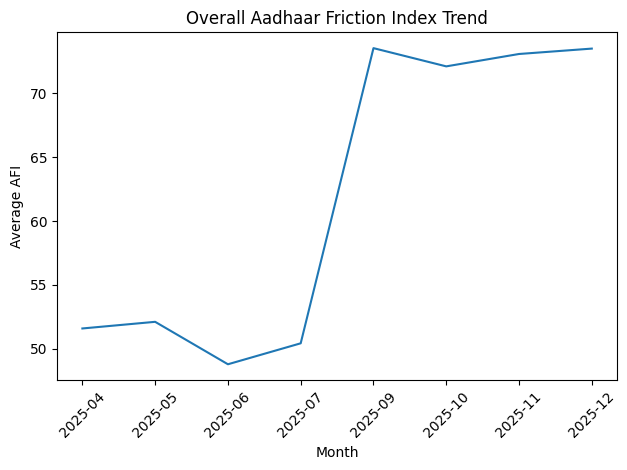

In [19]:
import matplotlib.pyplot as plt

# Aggregate across all states per month
overall_trend = (
    state_month_df
    .groupby('month')['AFI_mean']
    .mean()
    .reset_index()
)

plt.figure()
plt.plot(overall_trend['month'], overall_trend['AFI_mean'])
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Average AFI')
plt.title('Overall Aadhaar Friction Index Trend')
plt.tight_layout()
plt.show()


2. Which states face higher Aadhaar friction?

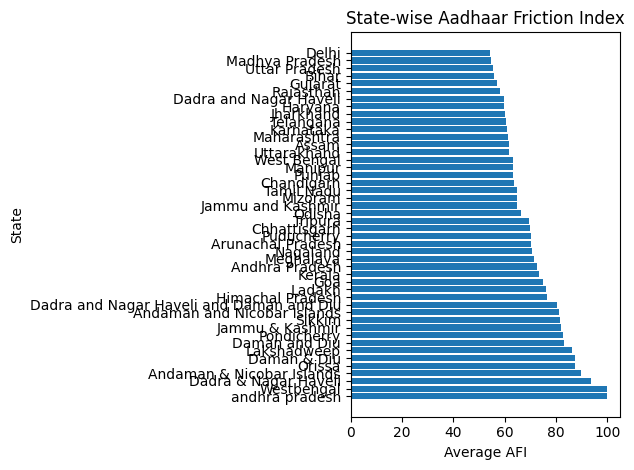

In [20]:
state_avg = (
    state_month_df
    .groupby('state')['AFI_mean']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure()
plt.barh(state_avg['state'], state_avg['AFI_mean'])
plt.xlabel('Average AFI')
plt.ylabel('State')
plt.title('State-wise Aadhaar Friction Index')
plt.tight_layout()
plt.show()


3. What contributes most to friction?

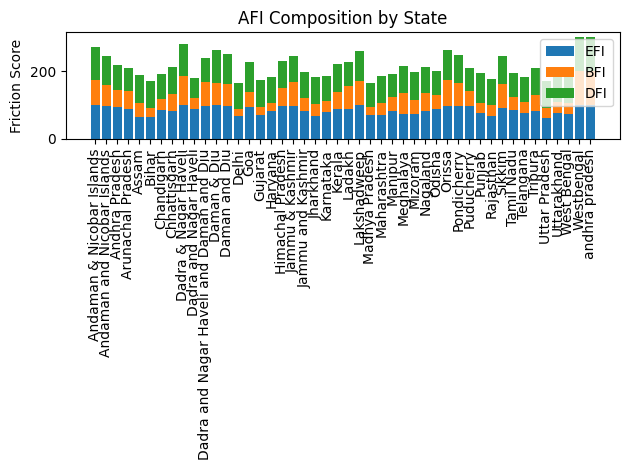

In [22]:
comp = (
    state_month_df
    .groupby('state')[['EFI_mean','BFI_mean','DFI_mean']]
    .mean()
    .reset_index()
)

plt.figure()
plt.bar(comp['state'], comp['EFI_mean'], label='EFI')
plt.bar(comp['state'], comp['BFI_mean'], bottom=comp['EFI_mean'], label='BFI')
plt.bar(
    comp['state'],
    comp['DFI_mean'],
    bottom=comp['EFI_mean'] + comp['BFI_mean'],
    label='DFI'
)

plt.xticks(rotation=90)
plt.ylabel('Friction Score')
plt.title('AFI Composition by State')
plt.legend()
plt.tight_layout()
plt.show()


4. karnataka

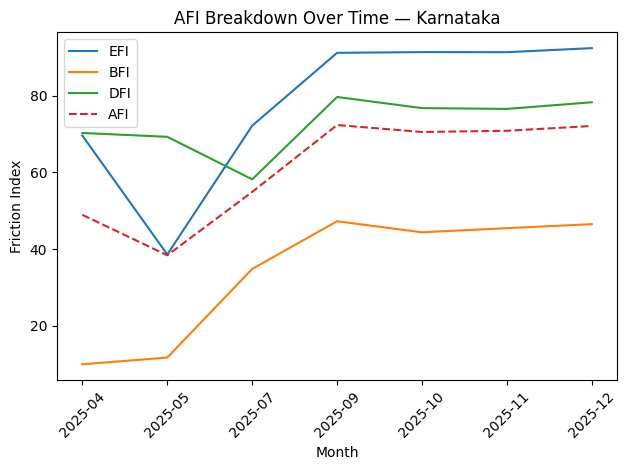

In [23]:
state_name = 'Karnataka'  # change to any state

state_trend = state_month_df[state_month_df['state'] == state_name]

plt.figure()
plt.plot(state_trend['month'], state_trend['EFI_mean'], label='EFI')
plt.plot(state_trend['month'], state_trend['BFI_mean'], label='BFI')
plt.plot(state_trend['month'], state_trend['DFI_mean'], label='DFI')
plt.plot(state_trend['month'], state_trend['AFI_mean'], label='AFI', linestyle='--')

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Friction Index')
plt.title(f'AFI Breakdown Over Time — {state_name}')
plt.legend()
plt.tight_layout()
plt.show()


# predictive analysis


In [24]:
from sklearn.linear_model import LinearRegression
import numpy as np


In [25]:
pred_df = state_month_df.copy()

# Convert month string to datetime
pred_df['month_dt'] = pd.to_datetime(pred_df['month'])

# Create numeric time index per state
pred_df['t'] = pred_df.groupby('state')['month_dt'].rank(method='dense')

pred_df.head()


,state,month,EFI_mean,BFI_mean,DFI_mean,AFI_mean,records,month_dt,t
0,Andaman & Nicobar Islands,2025-09,100.000000,63.650794,92.000000,84.877778,10,2025-09-01,1.0
1,Andaman & Nicobar Islands,2025-10,100.000000,54.074074,100.000000,83.925926,9,2025-10-01,2.0
2,Andaman & Nicobar Islands,2025-11,100.000000,90.476190,92.857143,94.523809,7,2025-11-01,3.0
3,Andaman & Nicobar Islands,2025-12,100.000000,90.000000,100.000000,96.500000,4,2025-12-01,4.0
4,Andaman and Nicobar Islands,2025-09,96.811121,51.443162,88.713187,78.502955,50,2025-09-01,1.0


In [26]:
state_name = 'Karnataka'  # change freely

state_data = pred_df[pred_df['state'] == state_name]

X = state_data[['t']]
y = state_data['AFI_mean']

model = LinearRegression()
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
last_t = state_data['t'].max()

future_t = np.array([
    last_t + 1,
    last_t + 2,
    last_t + 3
]).reshape(-1, 1)

future_afi = model.predict(future_t)

future_afi


c:\Users\DELL\anaconda3\envs\adar\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([82.57773866, 87.9384404 , 93.29914215])

C:\Users\DELL\AppData\Local\Temp\ipykernel_15968\826843602.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_months = pd.date_range(


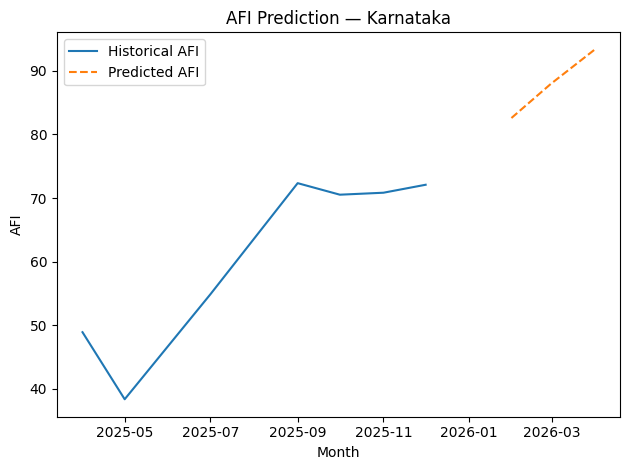

In [28]:
import matplotlib.pyplot as plt

# Historical
plt.figure()
plt.plot(state_data['month_dt'], y, label='Historical AFI')

# Future dates
future_months = pd.date_range(
    start=state_data['month_dt'].max(),
    periods=4,
    freq='M'
)[1:]

plt.plot(future_months, future_afi, linestyle='--', label='Predicted AFI')

plt.xlabel('Month')
plt.ylabel('AFI')
plt.title(f'AFI Prediction — {state_name}')
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
predictions = []

for state, group in pred_df.groupby('state'):
    if len(group) < 3:
        continue
        
    X = group[['t']]
    y = group['AFI_mean']
    
    model = LinearRegression()
    model.fit(X, y)
    
    last_t = group['t'].max()
    future_t = np.array([last_t + 1, last_t + 2, last_t + 3]).reshape(-1, 1)
    future_afi = model.predict(future_t)
    
    for i, afi_val in enumerate(future_afi, 1):
        predictions.append({
            'state': state,
            'month_offset': i,
            'predicted_AFI': afi_val
        })

pred_df_all = pd.DataFrame(predictions)
pred_df_all.head()


c:\Users\DELL\anaconda3\envs\adar\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\DELL\anaconda3\envs\adar\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\DELL\anaconda3\envs\adar\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\DELL\anaconda3\envs\adar\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\DELL\anaconda3\envs\adar\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature nam

,state,month_offset,predicted_AFI
0,Andaman & Nicobar Islands,1,101.323016
1,Andaman & Nicobar Islands,2,105.869471
2,Andaman & Nicobar Islands,3,110.415926
3,Andaman and Nicobar Islands,1,84.763825
4,Andaman and Nicobar Islands,2,86.177169
